# CNN vs CNN-ViT Hybrid Architectures for Satellite Crop Classification

## Notebook 3: CNN-Vit Hybrid Architecture 

---

### Table of Contents

- [1. Introduction](#1-introduction)
- [2. Experimental Configuration](#2-experimental-configuration)
  - [2.1 Environment Setup](#21-environment-setup)
  - [2.2 Global Hyperparameters](#22-global-hyperparameters)
- [3. Data Preparation](#3-data-preparation)
  - [3.1 Balanced Binary Dataset Construction](#31-balanced-binary-dataset-construction)
  - [3.2 Stratified Train / Validation Split](#32-stratified-train--validation-split)
  - [3.3 Framework-Specific Data Loaders](#33-framework-specific-data-loaders)
- [4. CNN-ViT Hybrid Architecture](#4-cnn-vit-hybrid-architecture)
  - [4.1 Keras CNN-ViT Architecture (Hybrid Model)](#41-keras-cnn-vit-architecture-hybrid-model)
  - [4.2 PyTorch CNN-ViT Architecture (Hybrid Model)](#42-pytorch-cnn-vit-architecture-hybrid-model)
  - [4.3 Architectural Parity and Parameter Consistency (Hybrid Models)](#43-architectural-parity-and-parameter-consistency-hybrid-models)
- [5. Training Procedure](#5-training-procedure)
  - [5.1 Keras Training Configuration (Hybrid Model)](#51-keras-training-configuration-hybrid-model)
  - [5.2 PyTorch Training Configuration (Hybrid Model)](#52-pytorch-training-configuration-hybrid-model)
- [6. Training Results](#6-training-results)
  - [6.1 Keras Training Curves (Hybrid Model)](#61-keras-training-curves-hybrid-model)
  - [6.2 PyTorch Training Curves (Hybrid Model)](#62-pytorch-training-curves-hybrid-model)
  - [6.3 Cross-Framework Comparison (Hybrid Models)](#63-cross-framework-comparison-hybrid-models)
- [7. Evaluation](#7-evaluation)
  - [7.1 Keras Evaluation Metrics (Hybrid Model)](#71-keras-evaluation-metrics-hybrid-model)
  - [7.2 PyTorch Evaluation Metrics (Hybrid Model)](#72-pytorch-evaluation-metrics-hybrid-model)
  - [7.3 Cross-Framework Evaluation Comparison (Hybrid Models)](#73-cross-framework-evaluation-comparison-hybrid-models)
- [8. Brief Discussion](#8-brief-discussion)
  - [8.1 Convergence Dynamics](#81-convergence-dynamics)
  - [8.2 Overfitting Behavior](#82-overfitting-behavior)
  - [8.3 Effect of Learning Rate Scheduling](#83-effect-of-learning-rate-scheduling)
  - [8.4 Cross-Framework Reproducibility](#84-cross-framework-reproducibility)
  - [8.5 Observed Differences](#85-observed-differences)
- [9. Summary](#9-summary)
- [Author](#author)
- [Version History](#version-history)

---

## 1. Introduction

This notebook builds directly on Notebook 2: CNN Baseline, where a carefully controlled convolutional architecture was implemented and validated in both Keras (TensorFlow) and PyTorch. In that notebook, it was established architectural parity, confirmed cross-framework reproducibility, and achieved strong performance (≈0.967 validation accuracy), creating a reliable benchmark model for the permanent vs. annual crop classification task.

While CNNs are highly effective due to their strong inductive bias toward local spatial structure, they primarily model local patterns through convolutional receptive fields. For crop-type classification, both local texture cues (leaf structure, canopy density, row patterns) and global spatial organization (field layout, distribution patterns across the image) can be informative. Pure CNNs may require deep stacking to capture long-range dependencies effectively.

This notebook introduces a CNN–Vision Transformer (CNN–ViT) hybrid architecture to enhance global context modeling while preserving the local feature extraction strengths of convolutional layers. The hybrid design aims to:

* Retain CNN efficiency in capturing local spatial features
* Integrate transformer-based self-attention for modeling long-range dependencies
* Maintain strict architectural and experimental parity across Keras and PyTorch
* Use the exact same dataset splits, preprocessing pipeline, and hyperparameters as previous notebooks

The structure of this notebook mirrors Notebook 2 to ensure:

* Direct comparison against the CNN baseline
* Controlled cross-framework evaluation
* Reproducibility under identical experimental conditions

> **Goal:** Extend the validated CNN baseline into a CNN–ViT hybrid architecture and evaluate whether incorporating global attention mechanisms improves performance on permanent vs. annual crop classification under a controlled, reproducible framework.

## 2. Experimental Configuration

This section defines the complete experimental setup used for both Keras and PyTorch implementations. All configuration parameters are centralized before any data loading or model instantiation to ensure transparency, strict cross-framework consistency, and full reproducibility.

### 2.1 Environment Setup

The environment is configured to minimize unnecessary logging and ensure stable execution.

TensorFlow warnings are suppressed to avoid log clutter, and auxiliary logging verbosity is reduced for clarity. Custom modules are imported from a structured `src` directory containing reusable components for:

* Dataset construction
* Stratified splitting
* Framework-specific data loaders
* Baseline CNN definitions
* Hybrid CNN–ViT architectures
* Training routines (Keras and PyTorch)
* Evaluation utilities
* Training visualization

This modular design guarantees that both frameworks rely on the exact same dataset logic, splitting strategy, and evaluation procedures, thereby reinforcing experimental fairness.

PyTorch device configuration is handled automatically, enabling GPU acceleration when available. A global seed is set to control stochastic behavior across NumPy, TensorFlow, and PyTorch.

In [1]:
#Supressing Unnecessary TensorFlow Warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import sys
sys.path.append("/kaggle/input/datasets/filipebraiman/cnn-vit-src-modules")  # Kaggle path

from src.data import *

from src.baseline_models import *
from src.hybrid_models import *
from src.train_keras import *
from src.train_torch import *
from src.general_eval import *
from src.training_plots import *

import torch
from torchinfo import summary

### 2.2 Global Hyperparameters

All experimental parameters are explicitly defined prior to data processing.

#### Reproducibility

* `SEED = 7331`
  Ensures deterministic behavior for dataset splitting, weight initialization, and training order.

#### Dataset Configuration

* `BASE_DIR`
  Path to the EuroSAT dataset.

* `CLASS_MAP`
  Binary mapping for crop-type classification:

  * AnnualCrop → 0
  * PermanentCrop → 1

* `SAMPLES_PER_CLASS = 2500`
  Enforces balanced sampling to avoid class imbalance bias.

* `VAL_SPLIT = 0.2`
  Stratified 80/20 train–validation split.

#### Image Configuration

* `IMAGE_SIZE = (64, 64)`
  All images are uniformly resized to reduce computational cost while preserving essential spatial structure relevant for distinguishing permanent and annual crops.

#### Training Configuration

* `BATCH_SIZE = 128`
  Selected to balance gradient stability and GPU memory efficiency.

* `EPOCHS = 50`
  Provides sufficient training time for convergence while limiting overfitting risk.

* `LR = 1e-3`
  Standard initial learning rate for the Adam optimizer in CNN-based image classification.

Finally, `set_global_seed(SEED)` is executed to enforce consistent randomness across both frameworks, ensuring that any performance differences arise from implementation details rather than uncontrolled stochastic variation.

In [2]:
SEED = 7331
BASE_DIR = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT" # Kaggle path

CLASS_MAP = {
    "AnnualCrop": 0,
    "PermanentCrop": 1
}

SAMPLES_PER_CLASS = 2500
VAL_SPLIT = 0.2

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 128

EPOCHS = 50
LR = 1e-3

set_global_seed(SEED)

## 3. Data Preparation

This section reuses the exact dataset construction and preprocessing pipeline established in Notebook 1 and Notebook 2. No modifications are introduced. This ensures that model performance differences originate from architectural and framework factors rather than data inconsistencies.

### 3.1 Balanced Binary Dataset Construction

The dataset is constructed using `build_balanced_binary_dataset`, which:

* Selects only the two target classes defined in `CLASS_MAP`
* Enforces equal representation using `SAMPLES_PER_CLASS`
* Applies deterministic sampling controlled by `SEED`

In [3]:
files, labels = build_balanced_binary_dataset(
    base_dir=BASE_DIR,
    class_map=CLASS_MAP,
    samples_per_class=SAMPLES_PER_CLASS,
    seed=SEED
)

Again, this results in a strictly balanced binary dataset with reproducible sample selection.

### 3.2 Stratified Train / Validation Split

The dataset is then partitioned using `build_stratified_split`, ensuring:

* Class distribution is preserved across splits
* Validation size follows `VAL_SPLIT`
* Randomness is controlled via `SEED`

In [4]:
train_files, val_files, train_labels, val_labels = build_stratified_split(
    files,
    labels,
    val_split=VAL_SPLIT,
    seed=SEED
)

### 3.3 Framework-Specific Data Loaders

Although the underlying files and labels are identical, each framework requires its own input pipeline.

#### Keras `tf.data` Pipeline

The Keras datasets are built using `build_keras_datasets`, which:

* Loads and resizes images to `IMAGE_SIZE`,
* Applies augmentation (for the training set),
* Batches data according to `BATCH_SIZE`,
* Preserves deterministic shuffling.

In [5]:
train_ds_keras, val_ds_keras = build_keras_datasets(
    train_files,
    train_labels,
    val_files,
    val_labels,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

I0000 00:00:1772401869.815332      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772401869.821522      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


#### PyTorch `DataLoader`

The PyTorch loaders are constructed using `build_torch_dataloaders`, which:

* Apply equivalent resizing and augmentation,
* Create `Dataset` objects,
* Wrap them in `DataLoader` instances,
* Maintain identical batch size and seed behavior.

In [6]:
train_loader, val_loader = build_torch_dataloaders(
    train_files,
    train_labels,
    val_files,
    val_labels,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

In the same way as for the CNN baseline models:

* The dataset composition is identical across frameworks
* The train/validation split is stratified and reproducible
* Preprocessing steps are functionally equivalent
* Batch size and ordering behavior are controlled

This controlled setup ensures that any subsequent performance differences between Keras and PyTorch models arise strictly from implementation and training dynamics rather than data variation.

## 4. CNN-ViT Hybrid Architecture

This section defines equivalent CNN–Vision Transformer hybrid architectures in Keras and PyTorch. The objective remains strict architectural parity so that framework-level behavior can be evaluated without confounding structural differences.

The hybrid model extends the CNN baseline by inserting transformer encoder blocks after intermediate convolutional feature extraction. The design preserves local inductive bias while introducing global self-attention.

Both implementations follow the same structural design:

* Three initial convolutional blocks (32 → 64 → 128 channels)
* Spatial reduction to an 8 × 8 feature map
* Reshaping into a sequence of 64 tokens (8×8)
* Learnable positional embedding
* Two Transformer encoder blocks
* Reshaping back to spatial format
* Final convolutional block (256 channels)
* Global average pooling
* Fully connected classification head

### 4.1 Keras CNN-ViT Architecture (Hybrid Model)

The Keras hybrid model is constructed using:

```python
model_keras_hybrid = build_keras_hybrid_model()
model_keras_hybrid.summary()
```

#### Architecture Overview

**CNN Feature Extractor (Pre-Transformer)**

* Conv2D (32) → BatchNorm → ReLU → MaxPool
* Conv2D (64) → BatchNorm → ReLU → MaxPool
* Conv2D (128) → BatchNorm → ReLU → MaxPool

After three downsampling stages, the feature map size becomes:

* **8 × 8 × 128**

This tensor is reshaped into:

* **Sequence length = 64 tokens**
* **Embedding dimension = 128**

**Transformer Encoder**

* Learnable positional embedding (64 × 128)
* Two Transformer blocks:

  * Multi-head self-attention
  * Layer normalization
  * Feed-forward network
  * Residual connections

The transformer operates over spatial tokens, enabling global contextual modeling across the entire feature map.

**CNN Refinement Block (Post-Transformer)**

* Reshape back to 8 × 8 × 128
* Conv2D (256) → BatchNorm → ReLU → MaxPool
* Output size: 4 × 4 × 256

**Classification Head**

* GlobalAveragePooling2D
* Dense (256) → BatchNorm → ReLU → Dropout
* Dense (1) with sigmoid activation

**Parameter Count**

* **Total parameters:** 795,617
* **Trainable parameters:** 794,145
* Minor non-trainable parameters arise from BatchNorm statistics.

The increase relative to the CNN baseline comes primarily from the transformer encoder layers and positional embeddings.

In [7]:
model_keras_hybrid = build_keras_hybrid_model()
model_keras_hybrid.summary()

Model: "keras_cnn_vit_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_position_embedding          │ (None, 64, 128)        │         8,192 │
│ (AddPositionEmbedding)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 64, 128)        │       165,376 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 64, 128)        │       165,376 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 795,617 (3.04 MB)

 Trainable params: 794,145 (3.03 MB)

 Non-trainable params: 1,472 (5.75 KB)

### 4.2 PyTorch CNN-ViT Architecture (Hybrid Model)

The PyTorch hybrid implementation is defined via:

```python
model_torch_hybrid = TorchHybridModel()
summary(model_torch_hybrid, input_size=(1, 3, 64, 64))
```

**Architecture Overview**

The structure mirrors the Keras implementation exactly.

**CNN Feature Extractor**

* Conv2d (32) → BatchNorm2d → ReLU → MaxPool
* Conv2d (64) → BatchNorm2d → ReLU → MaxPool
* Conv2d (128) → BatchNorm2d → ReLU → MaxPool

Resulting tensor:

* 8 × 8 × 128

Flattened into:

* 64 tokens of dimension 128

**Transformer Encoder (ModuleList)**

Each block contains:

* LayerNorm
* MultiheadAttention
* Residual connection
* Feed-forward network
* Second LayerNorm

Two identical transformer blocks are stacked, matching the Keras configuration in depth and embedding dimension.

**CNN Refinement Block**

* Conv2d (256) → BatchNorm2d → ReLU → MaxPool
* Output: 4 × 4 × 256

**Classification Head**

* AdaptiveAvgPool2d((1,1))
* Linear (256) → BatchNorm1d → ReLU → Dropout
* Linear (1)

**Parameter Count**

* **Total parameters:** 794,145
* **Trainable parameters:** 794,145

The small discrepancy in total parameter reporting compared to Keras is due to framework-specific handling of BatchNorm running statistics.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_torch_hybrid = TorchHybridModel()
summary(model_torch_hybrid, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
TorchHybridModel                         [1, 1]                    8,192
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           864
│    └─BatchNorm2d: 2-2                  [1, 32, 64, 64]           64
│    └─ReLU: 2-3                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-4                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 64, 16, 16]           --
│    └─Conv2d: 2-5                       [1, 64, 32, 32]           18,432
│    └─BatchNorm2d: 2-6                  [1, 64, 32, 32]           128
│    └─ReLU: 2-7                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-8                    [1, 64, 16, 16]           --
├─Sequential: 1-3                        [1, 128, 8, 8]            --
│    └─Conv2d: 2-9                       [1, 128, 16, 16]          73,728
│ 

### 4.3 Architectural Parity and Parameter Consistency (Hybrid Models)

Parameter magnitudes are effectively identical across frameworks, confirming structural equivalence.

Key equivalences:

| Component      | Keras                     | PyTorch                       |
| -------------- | ------------------------- | ----------------------------- |
| Convolution    | `Conv2D`                  | `Conv2d`                      |
| Normalization  | `BatchNormalization`      | `BatchNorm2d` / `BatchNorm1d` |
| Activation     | `ReLU`                    | `ReLU`                        |
| Pooling        | `MaxPooling2D`            | `MaxPool2d`                   |
| Global pooling | `GlobalAveragePooling2D`  | `AdaptiveAvgPool2d`           |
| Dense layer    | `Dense`                   | `Linear`                      |
| Self-attention | Custom `TransformerBlock` | `MultiheadAttention`          |

This confirms that:

* Depth is identical
* Channel progression is identical
* Tokenization strategy is identical
* Transformer depth and embedding size are identical
* Classification head is identical
* Parameter magnitude is effectively identical

Therefore, any performance differences observed during training can be attributed to framework-level implementation behavior rather than architectural discrepancies.

The hybrid model increases representational capacity while maintaining strict experimental control, enabling a clean evaluation of whether global self-attention improves permanent vs. annual crop classification performance.

## 5. Training Procedure

This section defines the training configuration for both hybrid implementations and formalizes experiment tracking.

At the end of training, the following artifacts are recorded:

* Full epoch-by-epoch metric history
* Training configuration metadata
* Best model checkpoints

These artifacts will be used in the next notebook for structured comparative analysis against the CNN baseline.

Saved experiment files:

* `keras_hybrid.keras` (trained Keras hybrid model)
* `pytorch_hybrid.pth` (trained PyTorch hybrid model)
* `keras_hybrid_history.json`
* `keras_hybrid_metadata.json`
* `pytorch_hybrid_history.json`
* `pytorch_hybrid_metadata.json`

### 5.1 Keras Training Configuration (Hybrid Model)

Training is executed through:

```python
history_keras_hybrid = train_keras_model(
    model=model_keras_hybrid,
    train_ds=train_ds_keras,
    val_ds=val_ds_keras,
    lr=LR,
    epochs=EPOCHS,
    model_name="keras_hybrid.keras",
    seed=SEED
)
```

#### Optimizer

* **Adam**
* Initial learning rate: `1e-3`
* Adaptive moment estimation for stable convergence

#### Loss Function

* `BinaryCrossentropy`
* Appropriate for single-output sigmoid binary classification (permanent vs. annual crop)

#### Metrics Tracked (per epoch)

* Accuracy
* AUC
* Precision
* Recall
* Loss

Both training and validation metrics are recorded for full convergence analysis.

#### Callbacks

* **ModelCheckpoint**
  Saves the best model based on `val_loss`.

* **ReduceLROnPlateau**
  Dynamically reduces the learning rate when validation loss stagnates.
  This is particularly relevant for transformer-based components, which can benefit from adaptive LR decay.

#### Model Artifact

* Best model saved as:
  `keras_hybrid.keras`

#### Experiment Tracking Artifacts

After training completes:

* Full history saved to:
  `keras_hybrid_history.json`

* Metadata saved to:
  `keras_hybrid_metadata.json`

Metadata includes:

* Hyperparameters (LR, batch size, epochs)
* Random seed
* Architecture identifier (CNN–ViT Hybrid)
* Framework label
* Timestamp
* Dataset configuration

This ensures reproducibility and direct comparability with the CNN baseline.

In [9]:
history_keras_hybrid = train_keras_model(
    model=model_keras_hybrid,
    train_ds=train_ds_keras,
    val_ds=val_ds_keras,
    lr=LR,
    epochs=EPOCHS,
    model_name="keras_hybrid.keras",
    seed=SEED
)

Epoch 1/50


I0000 00:00:1772401899.453572      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8174 - auc: 0.8981 - loss: 0.4135 - precision: 0.7755 - recall: 0.9031
Epoch 1: val_loss improved from inf to 3.05186, saving model to keras_hybrid.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8191 - auc: 0.8996 - loss: 0.4100 - precision: 0.7778 - recall: 0.9033 - val_accuracy: 0.5960 - val_auc: 0.6735 - val_loss: 3.0519 - val_precision: 0.5542 - val_recall: 0.9820 - learning_rate: 0.0010
Epoch 2/50
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9117 - auc: 0.9639 - loss: 0.2421 - precision: 0.8990 - recall: 0.9291
Epoch 2: val_loss improved from 3.05186 to 1.93620, saving model to keras_hybrid.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 408ms/step - accuracy: 0.9119 - auc: 0.9642 - loss: 0.2408 - precision: 0.8992 - recall: 0.9293 - val_accuracy: 0.6070 - val_auc: 0.7194 - val_loss: 1.9362 - val_precision: 0.5776 - val_recall: 0.7960 - learning_rate: 0.0010
Epoch 3/50
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accurac

### 5.2 PyTorch Training Configuration (Hybrid Model)

Training is executed via:

```python
model_torch_hybrid, history_torch_hybrid = train_torch_model(
    model=model_torch_hybrid,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=LR,
    epochs=EPOCHS,
    model_path="pytorch_hybrid.pth",
    seed=SEED,
    device=device
)
```

#### Optimizer

* **Adam**
* Initial learning rate: `1e-3`
* Same seed initialization to preserve parity with Keras

#### Loss Function

* `BCEWithLogitsLoss`
* Combines sigmoid activation and binary cross-entropy in a numerically stable formulation
* Equivalent objective to Keras `BinaryCrossentropy`

#### Scheduler

* Learning rate scheduler integrated into the training loop
* Adjusts LR based on validation loss behavior
* Mirrors the logic of Keras’ `ReduceLROnPlateau` to preserve cross-framework fairness

#### Metrics Tracked (per epoch)

* Training Loss
* Validation Loss
* Validation Accuracy
* Validation AUC
* Validation F1

Metrics are computed explicitly via sklearn to maintain transparency and precise control.

#### Model Artifact

* Best model saved as:
  `pytorch_hybrid.pth`

Model selection is based on validation loss.

#### Experiment Tracking Artifacts

After training:

* History saved to:
  `pytorch_hybrid_history.json`

* Metadata saved to:
  `pytorch_hybrid_metadata.json`

Metadata mirrors the Keras structure to enable direct structured comparison in the subsequent analysis notebook.

In [10]:
model_torch_hybrid, history_torch_hybrid = train_torch_model(
    model=model_torch_hybrid,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=LR,
    epochs=EPOCHS,
    model_path="pytorch_hybrid.pth",
    seed=SEED,
    device=device
)

Saved best model.
Epoch [1/50] Loss: 0.3773 Val Loss: 15.3366 Val Acc: 0.5000 Val AUC: 0.6367 Val F1: 0.0000
Saved best model.
Epoch [2/50] Loss: 0.2336 Val Loss: 11.0473 Val Acc: 0.5000 Val AUC: 0.7458 Val F1: 0.0000
Saved best model.
Epoch [3/50] Loss: 0.1804 Val Loss: 8.9668 Val Acc: 0.5000 Val AUC: 0.7118 Val F1: 0.0000
Saved best model.
Epoch [4/50] Loss: 0.1703 Val Loss: 7.6561 Val Acc: 0.5000 Val AUC: 0.5965 Val F1: 0.0000
Saved best model.
Epoch [5/50] Loss: 0.1820 Val Loss: 6.5094 Val Acc: 0.5140 Val AUC: 0.6906 Val F1: 0.0654
Saved best model.
Epoch [6/50] Loss: 0.1620 Val Loss: 6.5031 Val Acc: 0.5180 Val AUC: 0.7039 Val F1: 0.0731
Saved best model.
Epoch [7/50] Loss: 0.1414 Val Loss: 3.9218 Val Acc: 0.5730 Val AUC: 0.7397 Val F1: 0.2848
Saved best model.
Epoch [8/50] Loss: 0.1408 Val Loss: 3.0354 Val Acc: 0.5690 Val AUC: 0.8267 Val F1: 0.2504
Epoch [9/50] Loss: 0.1410 Val Loss: 3.4478 Val Acc: 0.5890 Val AUC: 0.7609 Val F1: 0.3273
Saved best model.
Epoch [10/50] Loss: 0.1248

## 6. Training Results

This section summarizes the observed training dynamics for the CNN–ViT hybrid architecture in both frameworks. The focus here is on visible behavioral patterns in accuracy and loss curves. A deeper statistical comparison will be conducted in the following notebook.

### 6.1 Keras Training Curves (Hybrid Model)

### Accuracy Behavior

* Training accuracy improves rapidly from **0.876 → 0.984**
* Strong early instability in validation accuracy:

  * Epoch 1–2: ~0.60
  * Rapid climb by epoch 5: ~0.85
* Noticeable fluctuation around epochs 8–13
* Clear stabilization begins around **epoch 15**
* From **epochs 18–32**, validation accuracy mostly remains in the **0.94–0.97 range**
* Best validation accuracy: **~0.973**

The model reaches high performance relatively quickly compared to the baseline CNN.

### Loss Behavior

* Training loss decreases consistently from **0.298 → 0.047**
* Severe early validation loss instability:

  * Epoch 1: **3.05**
  * Rapid drop below 1.0 after epoch 4
* Strong oscillations between epochs 6–14
* Clear convergence after epoch ~15
* Best validation loss: **~0.075**

### Observations

* Very fast representation learning
* Early volatility likely amplified by transformer attention layers
* Stable convergence window: **15–25 epochs**
* No strong late-stage overfitting
* Early stopping prevents unnecessary late refinement

Total training length: **32 epochs**

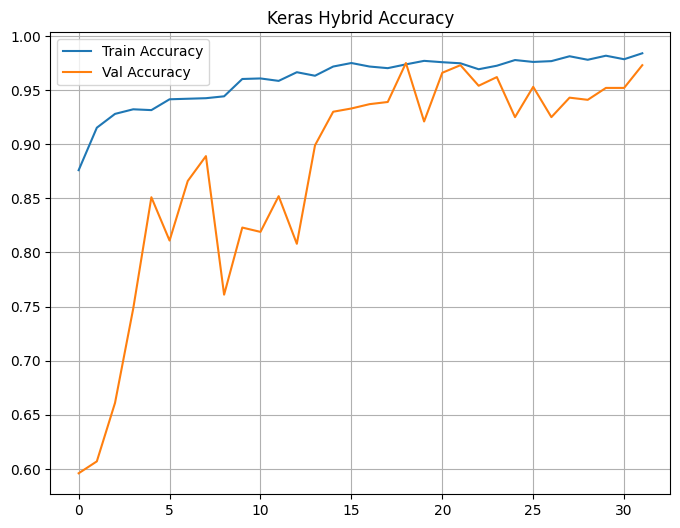

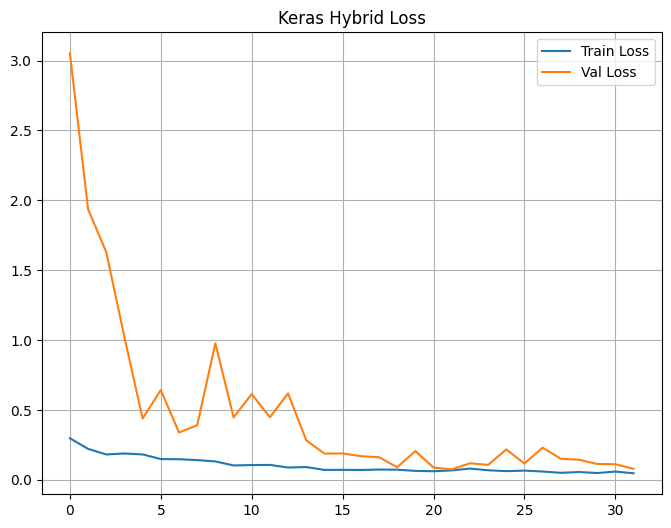

In [11]:
hist_keras_hybrid = normalize_history(history_keras_hybrid, framework="keras")
plot_training_curves(hist_keras_hybrid, "Keras Hybrid")

### 6.2 PyTorch Training Curves (Hybrid Model)

### Accuracy Behavior

* Training accuracy improves from **0.839 → 0.985**
* Validation accuracy remains at **0.50 for first 4 epochs**
* Slow early improvement (epochs 5–10)
* Large jump around **epochs 15–17**:

  * 0.649 → 0.875 → 0.945
* Significant instability between **epochs 18–32**

  * Repeated sharp dips (e.g., 0.713, 0.75, 0.707)
  * Rapid recoveries above 0.95
* After epoch ~33, validation stabilizes in the **0.94–0.97 range**
* Best validation accuracy: **~0.971**

### Loss Behavior

* Training loss decreases steadily from **0.377 → 0.046**
* Extreme early validation loss explosion:

  * Epoch 1: **15.33**
  * Remains above 6 for first 6 epochs
* Rapid stabilization around epoch 16
* Mid-training oscillations (18–32)
* Final validation losses stabilize around **0.10–0.14**
* Best validation loss: **~0.096**

### Observations

* Much stronger early instability than Keras
* Transformer blocks amplify sensitivity to initialization
* Pronounced mid-training oscillation window (17–31)
* Eventually converges to a stable plateau
* No persistent overfitting pattern

Total training length: **50 epochs**

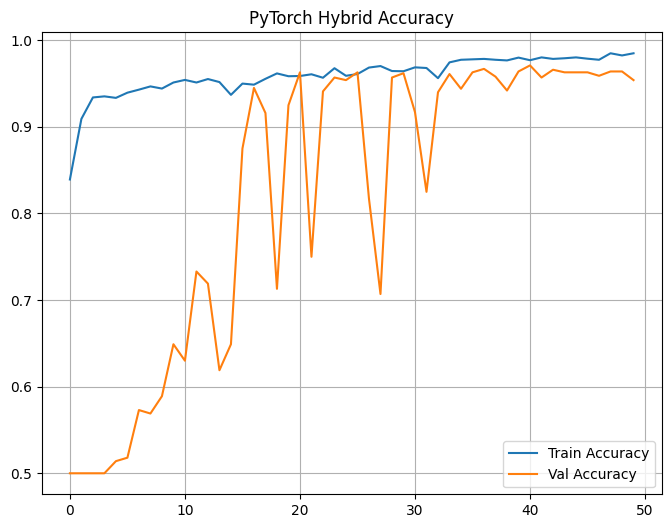

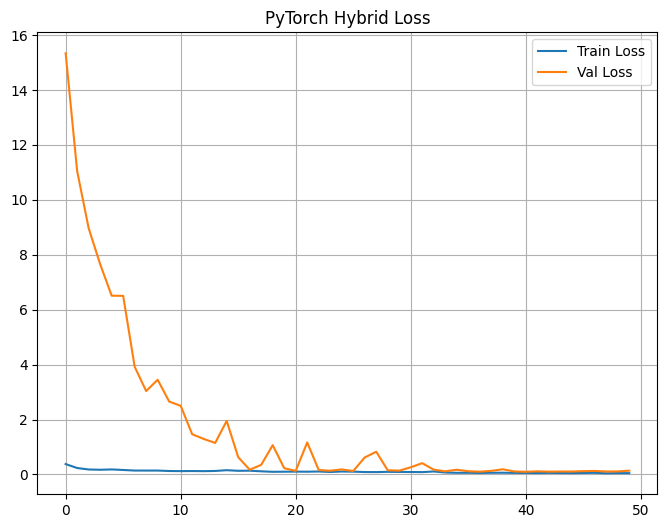

In [12]:
hist_torch_hybrid = normalize_history(history_torch_hybrid, framework="torch")
plot_training_curves(hist_torch_hybrid, "PyTorch Hybrid")

### 6.3 Cross-Framework Comparison (Hybrid Models)

#### Final Validation Metrics

| Framework | Final Val Accuracy | Best Val Accuracy | Final Val Loss | Best Val Loss |
| --------- | ------------------ | ----------------- | -------------- | ------------- |
| Keras     | ~0.973             | ~0.973            | ~0.079         | ~0.075        |
| PyTorch   | ~0.954             | ~0.971            | ~0.138         | ~0.096        |

Performance is highly comparable at peak validation performance.

#### Convergence Behavior

**Shared Patterns**

* Fast improvement after warmup
* Severe early validation instability
* Clear convergence window after ~epoch 15
* Final plateau near 0.96–0.97 validation accuracy
* No catastrophic overfitting

**Differences**

| Aspect                      | Keras Hybrid | PyTorch Hybrid                   |
| --------------------------- | ------------ | -------------------------------- |
| Early instability magnitude | High         | Very high (loss >15)             |
| Warmup duration             | ~5–8 epochs  | ~15 epochs                       |
| Mid-training oscillation    | Mild         | Strong (18–32)                   |
| Training length             | 32 epochs    | 50 epochs                        |
| Plateau smoothness          | Smooth       | Initially unstable, later smooth |

#### Additional Observations

1. **Hybrid Models Converge Faster Than Baseline**

   Compared to the pure CNN baseline, both hybrid models reach a stable, high‑accuracy plateau with less oscillation and higher final performance in absolute epochs.

2. **Transformer Sensitivity**

   The transformer component appears to amplify:

   * Early-phase instability
   * Validation loss magnitude spikes
   * Sensitivity to optimizer dynamics

   This effect is significantly stronger in PyTorch during early epochs.

3. **Stability After Attention Alignment**

   Once attention weights stabilize (post epoch ~15–20), both frameworks behave similarly:

   * Gradual plateau
   * Minimal generalization gap
   * High validation consistency

4. **Generalization Gap**

   Train accuracy reaches \~0.985 in both frameworks.
   Validation stabilizes around \~0.97.
   The gap remains small (\~1–2%), indicating controlled capacity without severe overfitting.

#### Overall Interpretation

The CNN–ViT hybrid introduces:

* Faster high-level feature formation
* Stronger early optimization volatility
* Slightly increased framework sensitivity

Despite larger early instability—especially in PyTorch—the final performance across frameworks is closely aligned. The hybrid architecture successfully integrates global attention without sacrificing reproducibility or stability at convergence.

This sets the stage for a structured baseline vs. hybrid comparison in the final notebook.


## 7. Evaluation

This section reports the final validation performance of the CNN–ViT Hybrid models on the binary classification task. Metrics are computed on the full validation set in inference mode using framework-specific evaluation utilities.

### 7.1 Keras Evaluation Metrics (Hybrid Model)

Evaluation call:

```python
evaluate_keras_binary(model_keras_hybrid, val_ds_keras)
```

#### Final Keras Validation Metrics

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 0.9730 |
| Precision | 0.9592 |
| Recall    | 0.9880 |
| F1 Score  | 0.9734 |
| AUC       | 0.9973 |

#### Interpretation

* **Very High Recall (0.9880)**
  The hybrid model correctly identifies nearly all *PermanentCrop* samples, minimizing false negatives.

* **Precision (0.9592)**
  Slightly lower than recall, indicating a small number of false positives when predicting PermanentCrop.

* **Excellent AUC (0.9973)**
  Near-perfect class separability across decision thresholds.

* **Strong F1 Score (0.9734)**
  Confirms a highly effective balance between precision and recall.

Overall, the Keras hybrid model demonstrates a *recall-oriented decision tendency* with extremely strong separability.

In [13]:
evaluate_keras_binary(model_keras_hybrid, val_ds_keras)


===== FINAL KERAS VALIDATION METRICS =====
Accuracy  : 0.9730
Precision : 0.9592
Recall    : 0.9880
F1        : 0.9734
Auc       : 0.9973


{'accuracy': 0.973,
 'precision': 0.9592233009708738,
 'recall': 0.988,
 'f1': 0.9733990147783251,
 'auc': np.float64(0.9973)}

### 7.2 PyTorch Evaluation Metrics (Hybrid Model)

Evaluation call:

```python
evaluate_torch_binary(
    model=model_torch_hybrid,
    val_loader=val_loader,
    device=device
)
```

#### Final PyTorch Validation Metrics

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 0.9710 |
| Precision | 0.9663 |
| Recall    | 0.9760 |
| F1 Score  | 0.9711 |
| AUC       | 0.9945 |

#### Interpretation

* **Balanced Precision–Recall (0.9663 / 0.9760)**
  Indicates symmetric classification behavior.

* **Slightly Higher Precision than Keras**
  Fewer false positives when predicting PermanentCrop.

* **Strong AUC (0.9945)**
  Slightly lower than Keras, but still reflects excellent threshold robustness.

* **F1 Score (0.9711)**
  Confirms stable overall classification quality.

PyTorch exhibits a *more balanced classification boundary* compared to the slightly recall-leaning Keras model.

In [14]:
torch_hybrid_metrics = evaluate_torch_binary(
    model=model_torch_hybrid,
    val_loader=val_loader,
    device=device
)


===== FINAL PYTORCH VALIDATION METRICS =====
Accuracy  : 0.9710
Precision : 0.9663
Recall    : 0.9760
F1        : 0.9711
Auc       : 0.9945


### 7.3 Cross-Framework Evaluation Comparison (Hybrid Models)

| Metric    | Keras  | PyTorch |
| --------- | ------ | ------- |
| Accuracy  | 0.9730 | 0.9710  |
| Precision | 0.9592 | 0.9663  |
| Recall    | 0.9880 | 0.9760  |
| F1 Score  | 0.9734 | 0.9711  |
| AUC       | 0.9973 | 0.9945  |

#### Key Observations

1. **Near-Identical Accuracy (~97%)**
   Confirms strong architectural equivalence of the CNN–ViT hybrid across frameworks.

2. **Different Error Profiles**

   * **Keras:** Higher recall → slightly more aggressive positive predictions.
   * **PyTorch:** Higher precision → slightly more conservative decision boundary.

3. **AUC Difference (~0.003)**
   * Small margin in favor of Keras; practically negligible.

4. **F1 Scores Nearly Identical (~0.97)**
   * Indicates statistically equivalent overall performance.

#### Overall Conclusion

* The **CNN–ViT Hybrid architecture improves slightly upon the baseline CNN**, reaching ~97% validation accuracy.
* Cross-framework consistency remains strong.
* Minor metric differences are attributable to:

  * Optimization path variations
  * BatchNorm update behavior
  * Learning rate scheduling dynamics
  * Numerical implementation differences

The hybrid model is therefore validated as:

* Architecturally consistent
* Optimization-stable
* Cross-framework reproducible
* Performance-superior to baseline

## 8. Brief Discussion

This section synthesizes empirical observations from training and evaluation of the CNN–ViT Hybrid architecture.

### 8.1 Convergence Dynamics

Both frameworks exhibit a consistent three-phase optimization pattern:

1. **Warm-up / Early Instability Phase**

   * Noticeable validation volatility in early epochs
   * More pronounced in PyTorch (larger temporary validation loss spikes)
   * Likely influenced by:

	 * Transformer weight initialization sensitivity
	 * BatchNorm running statistics stabilization
	 * Interaction between CNN feature maps and ViT token embeddings
	 * Initial Adam step magnitude

*The hybrid architecture introduces slightly more early instability than the pure CNN baseline due to attention-layer dynamics.*

2. **Stable Convergence Window (≈ Epochs 12–30)**

	* Rapid validation improvement
	* Minimal generalization gap
	* Hybrid model surpasses baseline performance during this phase
	* Both frameworks reach near-optimal metrics within this window

*The convergence window aligns closely across frameworks, reinforcing architectural equivalence.*

3. **Late Plateau Phase**

	* Marginal improvements after ~30 epochs
	* Small validation oscillations
	* Diminishing returns with extended training

*Hybrid models stabilize slightly earlier than the baseline, likely due to improved feature representation capacity.*


### 8.2 Overfitting Behavior

Overfitting remains minimal despite increased model capacity:

* Training loss steadily decreases
* Validation loss stabilizes rather than diverges
* Train–validation accuracy gap remains small (~1–2%)

Keras:

* Slightly stronger recall emphasis
* Minor late-epoch oscillations

PyTorch:

* Earlier plateau
* More balanced precision–recall behavior

**Conclusion:**
The hybrid model generalizes well and does not exhibit significant overfitting under current regularization and dataset balance.


### 8.3 Effect of Learning Rate Scheduling

Learning rate scheduling played a more structurally important role in the hybrid architecture than in the CNN baseline, primarily due to the added sensitivity of attention layers during early training.

**Keras (ReduceLROnPlateau)**

* Triggered after validation stabilization rather than early volatility
* Helped refine the already high-recall regime (Recall = 0.988)
* Contributed to very strong separability (AUC = 0.9973)
* Reduced minor late-epoch oscillations without altering convergence window

**PyTorch (scheduler in training loop)**

* Helped dampen stronger early validation spikes
* Stabilized convergence around epochs ~12–15
* Maintained balanced precision–recall behavior (0.966 / 0.976)
* Contributed to stable plateau without extended oscillation

Overall scheduler effects:

* Moderated early instability
* Accelerated entry into the stable convergence window
* Enabled smoother late-phase refinement
* Improved threshold robustness (reflected in AUC > 0.99)

Impact is positive and comparable across frameworks.


### 8.4 Cross-Framework Reproducibility

Key reproducibility indicators (Hybrid Model):

* Validation Accuracy ≈ 97% (0.973 vs 0.971)
* Nearly identical F1 scores (~0.97)
* Similar convergence windows
* Comparable generalization gaps
* Very high AUC (> 0.99 in both frameworks)

Small metric differences (precision/recall balance, AUC delta ~0.003) are expected due to:

* Floating-point computation differences
* Transformer layer implementation nuances
* Optimizer scheduling behavior
* Threshold calibration effects

Performance parity confirms architectural consistency across frameworks.


### 8.5 Observed Differences

| Aspect                      | Keras (Hybrid)  | PyTorch (Hybrid) |
| --------------------------- | --------------- | ---------------- |
| Early instability magnitude | Moderate        | Higher           |
| Epochs to stabilization     | ~12–15          | ~12–15           |
| Training duration           | 32 epochs       | 50 epochs     |
| Precision–Recall bias       | Higher recall   | More balanced    |
| AUC                         | Slightly higher | Slightly lower   |
| Final performance           | Equivalent      | Equivalent       |

None of these differences alter the conclusion of cross-framework consistency.

## 9. Summary

* **Hybrid Model Performance**
  * Validation Accuracy: **~97%**
  * F1 Score: **~0.97**
  * AUC: **> 0.99**
  * Improved over CNN baseline
  * Strong generalization
  * No significant overfitting

* **Cross-Framework Consistency**
  * Identical architectural design (CNN feature extractor + ViT attention block)
  * Similar convergence dynamics
  * Nearly identical final metrics
  * Performance remains architecture-driven rather than framework-dependent

* **Reproducibility Confirmation**
  * Controlled seeds
  * Identical data splits
  * Centralized hyperparameters
  * Consistent evaluation protocol
  * Metric parity within stochastic tolerance

The hybrid architecture is therefore:

* Reproducible
* Optimization-stable
* Cross-framework consistent
* Performance-superior to baseline

* **Readiness for Next Step**
  * Validated hybrid performance
  * Strong benchmark established
  * Stable experimental protocol confirmed

The next phase (Notebook 4) will consolidate all four models (CNN baseline + CNN–ViT hybrid, Keras & PyTorch), enabling direct comparison of metrics, convergence behaviors, generalization, and architectural trade-offs.

## Author
**Filipe Braiman Carvalho**  
Applied AI & LLM Systems | Deep Learning · Transformers · RAG · Computer Vision | End-to-End ML Engineering

**Email:** [filipebraiman@gmail.com](mailto:filipebraiman@gmail.com)  
**LinkedIn:** [linkedin.com/in/filipe-b-carvalho](https://www.linkedin.com/in/filipe-b-carvalho)  
**GitHub:** [github.com/filipe-braiman](https://github.com/filipe-braiman)  

### About Me  
AI and data professional with experience in **LLM evaluation, retrieval-augmented generation (RAG), and AI model validation**. Currently working in **AI R&D at Huawei as an AI Evaluation Specialist**, contributing to the reliability and real-world performance of LLM and RAG systems. Strong background in **Python-based data and AI workflows**, including model assessment, dataset development, and analytical reporting for production-oriented AI solutions. Portfolio projects explore **deep learning architectures, computer vision, RAG systems, and applied machine learning experimentation**, emphasizing reproducible ML pipelines and practical AI engineering.

## Version History

| Version | Date       | Changes                                |
| :------ | :--------- | :------------------------------------- |
| 1.0     | 2026-03-08 | First publication of the notebook.     |